In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df = pd.read_csv("creditcard.csv")

In [36]:
print(df.shape)
print(df['Class'].value_counts())

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


In [37]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


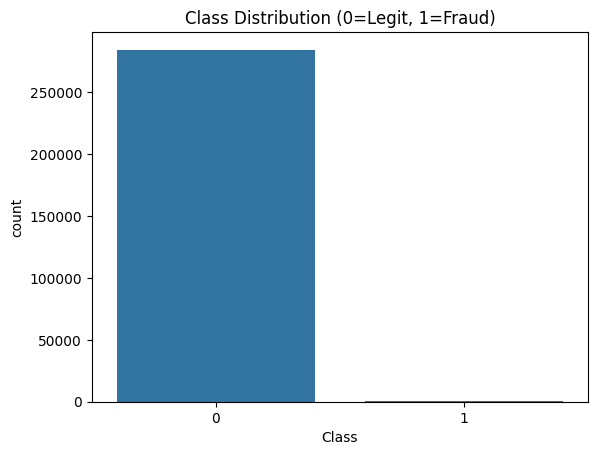

In [38]:
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0=Legit, 1=Fraud)')
plt.show()

In [39]:
print(df['Amount'].describe())
print(df['Time'].describe())

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64
count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64


In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [41]:
df = df.drop('Time', axis=1)
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])

In [42]:
X = df.drop('Class', axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [43]:
print(X_train.shape, X_test.shape)

(227845, 29) (56962, 29)


In [44]:
print(y_train.value_counts())

Class
0    227451
1       394
Name: count, dtype: int64


In [45]:
from imblearn.over_sampling import SMOTE

In [46]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

In [47]:
print(y_train_sm.value_counts())

Class
0    227451
1    227451
Name: count, dtype: int64


In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

In [49]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_sm, y_train_sm)
lr_pred = lr.predict(X_test)

In [50]:
print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr_pred))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962

ROC-AUC: 0.9459151731880147


In [51]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_sm, y_train_sm)
rf_pred = rf.predict(X_test)

In [52]:
print("=== Random Forest ===")
print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_pred))

=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9131597912096746


In [64]:
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train_sm, y_train_sm)
xgb_pred = xgb.predict(X_test)

In [65]:
print("=== XGBoost ===")
print(classification_report(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_pred))

=== XGBoost ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.69      0.87      0.77        98

    accuracy                           1.00     56962
   macro avg       0.84      0.93      0.88     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9333305459212384


In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

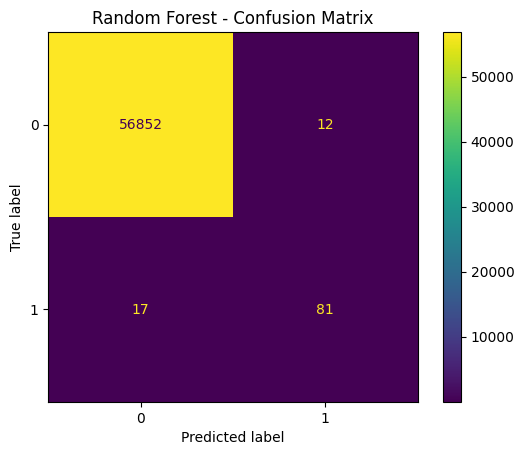

In [67]:
cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Random Forest - Confusion Matrix')
plt.show()

In [68]:
from sklearn.metrics import roc_curve, auc

In [69]:
fpr, tpr, _ = roc_curve(y_test, rf.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)

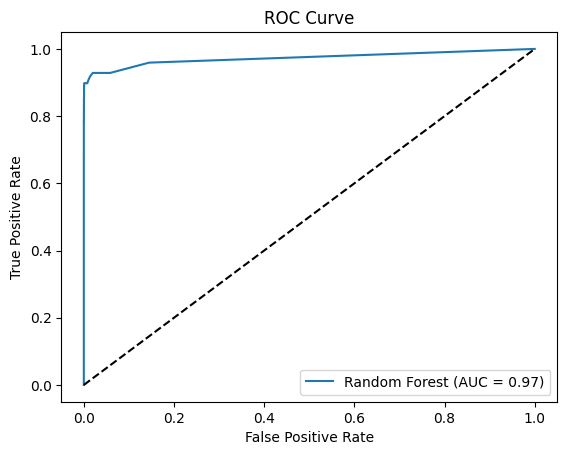

In [70]:
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [71]:
import joblib

In [72]:
joblib.dump(rf, 'fraud_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model saved successfully")

Model saved successfully


In [73]:
import os

In [74]:
print(os.listdir())

['.anaconda', '.antigravity', '.bash_history', '.cache', '.codex', '.conda', '.continuum', '.copilot', '.dbus-keyrings', '.gemini', '.git-for-windows-updater', '.gitconfig', '.idlerc', '.ipynb_checkpoints', '.ipython', '.junie', '.jupyter', '.lesshst', '.matplotlib', '.node_repl_history', '.python_history', '.viminfo', '.vscode', '.Xilinx', 'AIML LAB EXAM.ipynb', 'anaconda3', 'AppData', 'Application Data', 'Assignment 1.ipynb', 'Assignment 2.ipynb', 'Assignment 3.ipynb', 'Assignment 4.ipynb', 'Assignment 5.ipynb', 'Assignment 6.ipynb', 'bank_data.xlsx', 'basic_js.html', 'Cafe_sales_cleaned.csv', 'Code Red', 'Contacts', 'Cookies', 'creditcard.csv', 'CrossDevice', 'crowdsourced-verification', 'Dataset of Diabetes .csv', 'deception-detector', 'Desktop', 'Documents', 'Downloads', 'ecommerce_data.xlsx', 'Favorites', 'fitness_data.xlsx', 'Fraud_Detection.ipynb', 'fraud_model.pkl', 'gender_submission.csv', 'hardhat.config.js', 'health_data.xlsx', 'IdeaProjects', 'Linear Regression.ipynb', 'Li